# Import Libraries

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from matplotlib.ticker import FuncFormatter

# Import Data

In [131]:
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\data-1779767889227.csv")

In [132]:
df['bulan'] = pd.to_datetime(df['bulan'])

In [133]:
df = df.sort_values('bulan')

In [134]:
df.head()

,bulan,mcc_description,total_amount,amount_bulan_lalu,mom_growth_pct,status_mcc
0,2025-02-01,Accessory and Apparel Stores-Miscellaneous,457803281.0,140165632.0,226.62,Growth
231,2025-02-01,Automobile and Truck Dealers-(Used Only)-Sales,2000167.0,3567945.0,-43.94,Decline
2281,2025-02-01,Passenger Railways,11897000.0,24075000.0,-50.58,Decline
1364,2025-02-01,Family Clothing Stores,225069626.0,226983016.0,-0.84,Stable
513,2025-02-01,Campgrounds and Trailer Parks,752900.0,130000.0,479.15,Growth


In [135]:
bulan_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'Mei', 6: 'Jun',
    7: 'Jul', 8: 'Agu', 9: 'Sep', 10: 'Okt', 11: 'Nov', 12: 'Des'
}

In [136]:
df['nama_bulan'] = df['bulan'].dt.month.map(bulan_map) + ' ' + df['bulan'].dt.year.astype(str)

In [137]:
df.head()

,bulan,mcc_description,total_amount,amount_bulan_lalu,mom_growth_pct,status_mcc,nama_bulan
0,2025-02-01,Accessory and Apparel Stores-Miscellaneous,457803281.0,140165632.0,226.62,Growth,Feb 2025
231,2025-02-01,Automobile and Truck Dealers-(Used Only)-Sales,2000167.0,3567945.0,-43.94,Decline,Feb 2025
2281,2025-02-01,Passenger Railways,11897000.0,24075000.0,-50.58,Decline,Feb 2025
1364,2025-02-01,Family Clothing Stores,225069626.0,226983016.0,-0.84,Stable,Feb 2025
513,2025-02-01,Campgrounds and Trailer Parks,752900.0,130000.0,479.15,Growth,Feb 2025


# EDA

## Data Visualization

In [138]:
top_10_mcc = df.groupby('mcc_description')['mom_growth_pct'].mean().nlargest(10).index

In [139]:
df_top10 = df[df['mcc_description'].isin(top_10_mcc)]

#### Top MCC by MoM gowth


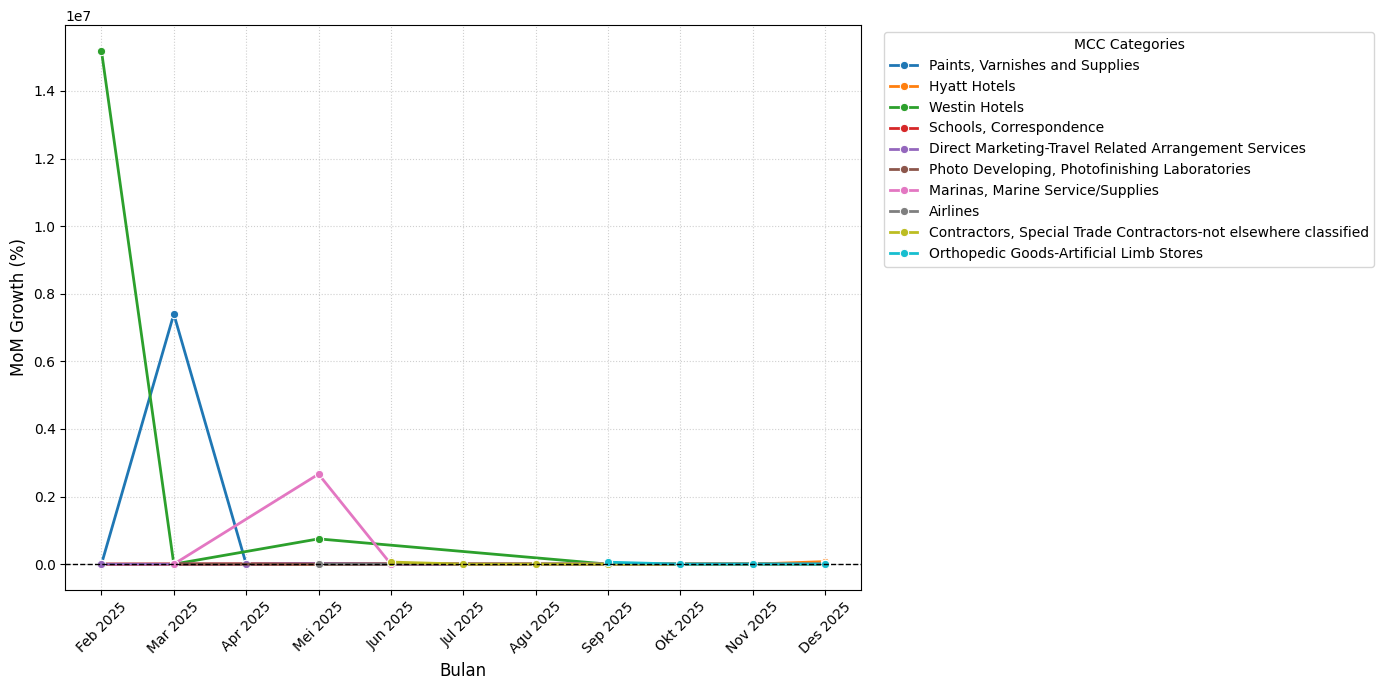

In [140]:
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_top10, 
    x='nama_bulan',       
    y='mom_growth_pct', 
    hue='mcc_description', 
    marker='o',
    linewidth=2,
    sort=False           
)

plt.xlabel('Bulan', fontsize=12)
plt.ylabel('MoM Growth (%)', fontsize=12)
plt.xticks(rotation=45)
plt.axhline(0, color='black', linestyle='--', linewidth=1) 
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='MCC Categories')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

#### Top MCC by transaction volume

Visualisasi jika ingin melihat bagaimana perkembangannya tiap bulan

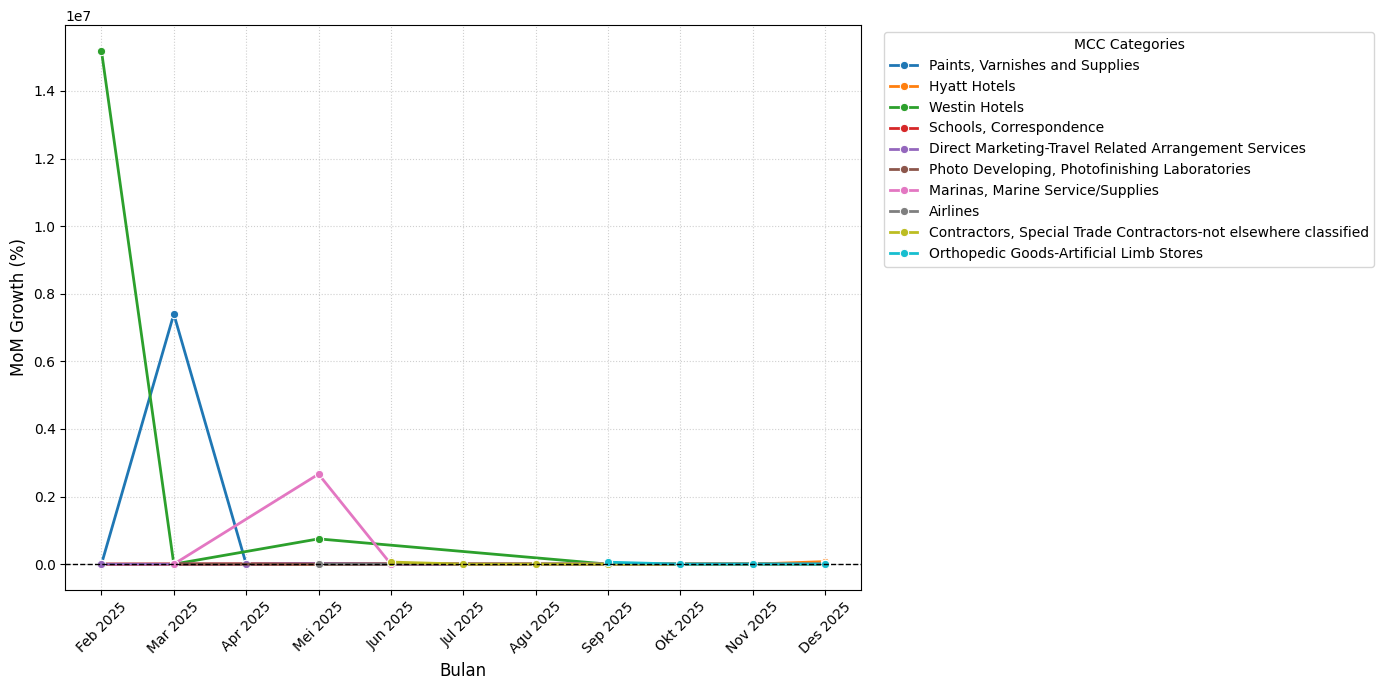

In [141]:
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_top10,
    x='nama_bulan',
    y='mom_growth_pct',
    hue='mcc_description',
    marker='o',
    linewidth=2,
    sort=False
)

plt.xlabel('Bulan', fontsize=12)
plt.ylabel('MoM Growth (%)', fontsize=12)
plt.xticks(rotation=45)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='MCC Categories')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

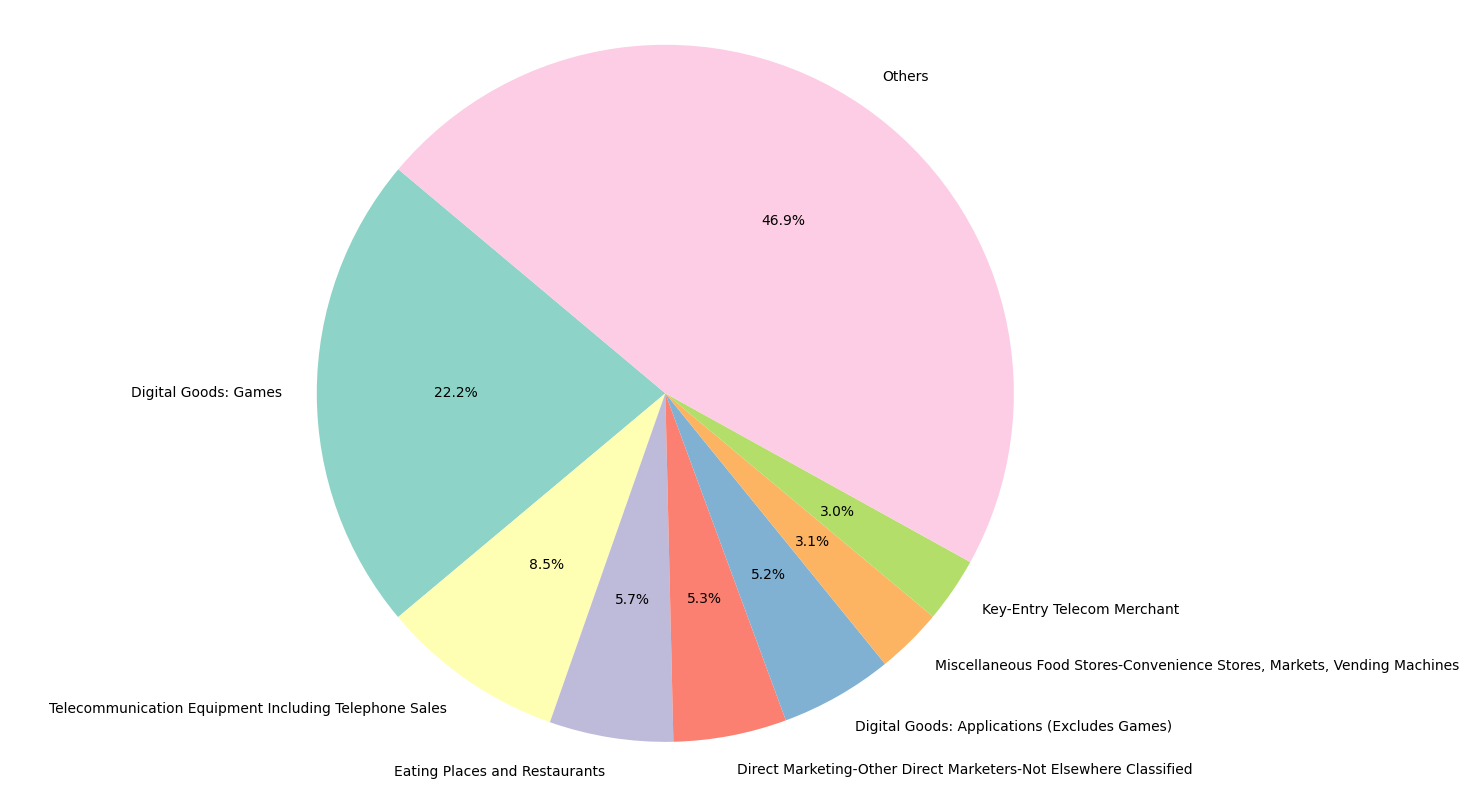

In [ ]:
revenue_per_mcc = df.groupby('mcc_description')['total_amount'].sum().sort_values(ascending=False)

pie_data = revenue_per_mcc.head(7).copy()
others_revenue = revenue_per_mcc.iloc[5:].sum()

if others_revenue > 0:
    pie_data['Others'] = others_revenue

plt.figure(figsize=(15, 8))
plt.pie(
    pie_data, 
    labels=pie_data.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.Set3.colors
)

plt.axis('equal') 
plt.tight_layout()

plt.show()

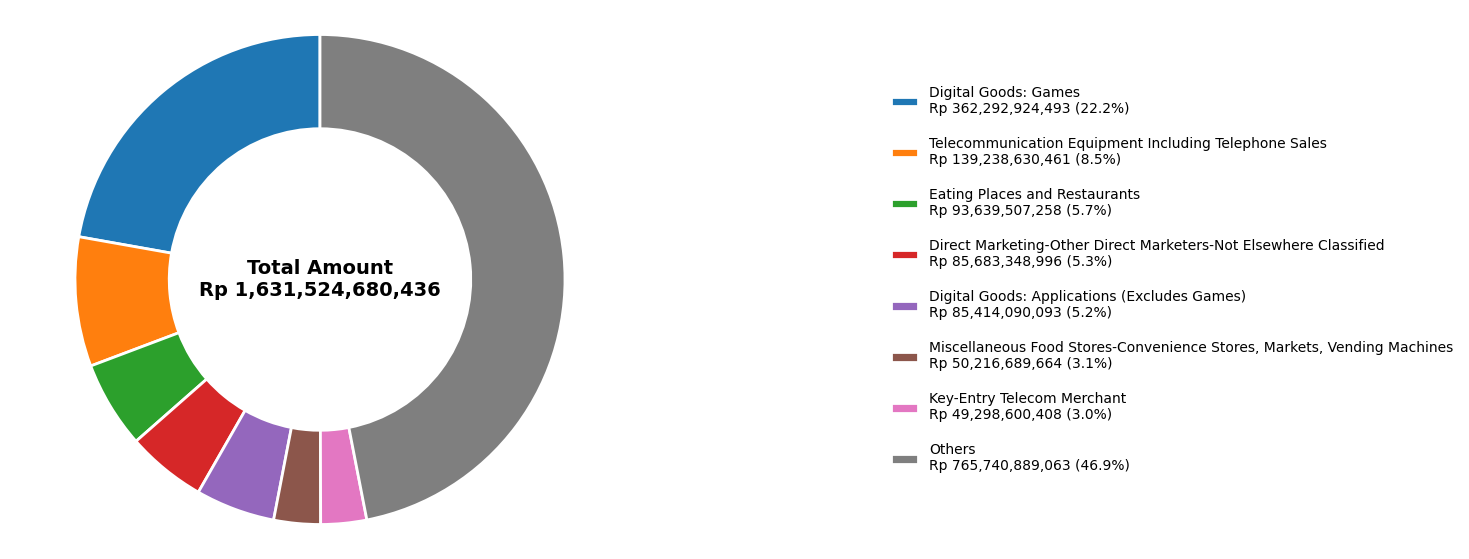

In [143]:
total_all = pie_data.sum()
legend_labels = [
    f"{idx}\nRp {val:,.0f} ({(val/total_all)*100:.1f}%)" 
    for idx, val in zip(pie_data.index, pie_data)
]

fig, ax = plt.subplots(figsize=(8, 7))

wedges, _ = ax.pie(
    pie_data, 
    startangle=90, 
    colors=plt.cm.tab10.colors,
    radius=1.3,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)

ax.text(
    0, 0, 
    f"Total Amount\nRp {total_all:,.0f}", 
    ha='center', va='center', 
    fontsize=14, fontweight='bold'
)

ax.legend(
    wedges, legend_labels, 
    loc="center left", 
    bbox_to_anchor=(1.4, 0.5), 
    frameon=False, 
    labelspacing=1.5
)

plt.axis('equal') 

plt.show()